In [183]:
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.control_flow import scan
from numpyro.infer import MCMC, NUTS
from numpyro.infer import Predictive
# posterior sample
import arviz as az
import jax
import jax.numpy as jnp
import jax.random as random
from tqdm import tqdm
import pandas as pd
import numpy as np
import re
from datetime import datetime
from IPython.display import Markdown, display, HTML
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.lines import Line2D
from func_show_results import sddr_normal

mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,

        "axes.linewidth": 1.0,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.25,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    })

mpl.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
})

import warnings
warnings.simplefilter('ignore')
def get_model_number(model_str):
    nums = re.findall(r'\d+', model_str)
    if nums:
        return int(nums[-1])
    else:
        return None
colors = ['black', 'blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']


from func_data_build import build_dataset
data = build_dataset("../data").dropna()

In [184]:
# for MCMC
pi = jnp.array(data['pi_ppi'],dtype=jnp.float64)
pi_prev = jnp.array(data['pi_ppi_prev'],dtype=jnp.float64)
pi_expect = jnp.array(data['Epi_spf_gdp'],dtype=jnp.float64)
N = jnp.array(data['N'],dtype=jnp.float64)
Nhat = jnp.array(data['N_BN_cycle'],dtype=jnp.float64)
Nbar = jnp.array(data['N_BN_trend'],dtype=jnp.float64)
Y = jnp.array(data['output'],dtype=jnp.float64)
x = jnp.array(data['unemp_gap'],dtype=jnp.float64)
x_prev = jnp.array(data['unemp_gap_prev'],dtype=jnp.float64)

# x = jnp.array(data['output_gap_BN'],dtype=jnp.float64)
# x_prev = jnp.array(data['output_gap_BN_prev'],dtype=jnp.float64)

# x = jnp.array(data['markup_BN_inv'],dtype=jnp.float64)
# x_prev = jnp.array(data['markup_BN_inv_prev'],dtype=jnp.float64)

# Prior distributions

In [185]:
alpha_mu = 0.5
alpha_sigma = 0.2
kappa_mu = 0.1
kappa_sigma = 0.2
theta_mu = 0.1
theta_sigma = 0.2
delta_mu = 0.1
delta_sigma = 0.2
beta_mu = 0.1
beta_sigma = 0.2
phi_1_mu = 0.7
phi_1_sigma = 0.2
phi_2_mu = 0.2
phi_2_sigma = 0.2
phi_3_mu = 0.2
phi_3_sigma = 0.2

gamma_mu = 0
gamma_sigma = 0.2

def set_prior_distributions():
    priors = {
        # NKPC params
        "alpha"      : dist.Normal(alpha_mu, alpha_sigma),
        "kappa"      : dist.Normal(kappa_mu, kappa_sigma),
        "kappa0"     : dist.Normal(kappa_mu, kappa_sigma),
        "theta"      : dist.Normal(theta_mu, theta_sigma), 
        "delta"      : dist.Normal(delta_mu, delta_sigma),  
        "gamma"      : dist.Normal(gamma_mu, gamma_sigma),  
        "beta"       : dist.Normal(beta_mu, beta_sigma), 
        "phi_1"      : dist.Normal(phi_1_mu, phi_1_sigma),
        "phi_2"      : dist.Normal(phi_2_mu, phi_2_sigma),
        "phi_3"      : dist.Normal(phi_3_mu, phi_3_sigma),
        # Sigma
        "n"          : dist.Normal(0, 1), 
        # non informative priors
        "sigma_u"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_eps"  : dist.InverseGamma(0.001, 0.001),  
        "sigma_v"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_mu"   : dist.InverseGamma(0.001, 0.001),  
        "sigma_e"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_eta"  : dist.InverseGamma(0.001, 0.001),  
        "sigma_zeta"  : dist.InverseGamma(0.001, 0.001),  
    }
    return priors

In [186]:
# ---------------- MCMC run configuration ---------------
warmup = 1000
samples = 4000
chains = 2
# Target acceptance rate: lower values speed up sampling but may increase divergences.
TARGET_ACCEPT = 0.95
CHAIN_METHOD = "parallel"
PROGRESS_BAR = True

# ==================================================================================================
# for reproducibility
rng_key = jax.random.PRNGKey(0)
rng_keys = jax.random.split(rng_key, chains)
numpyro.enable_x64()

---
## CES (Benchmark)
$$
\pi_{t} = \alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}+e_{t}\\
x_{t} = \phi_1 x_{t-1} + \zeta_{t}\\
\begin{bmatrix}e_t\\ \zeta_t\end{bmatrix}\sim N\!\left(0,\begin{bmatrix}\sigma_e^2&\sigma_{e\zeta}\\ \sigma_{e\zeta}&\sigma_\zeta^2\end{bmatrix}\right)
$$

In [187]:
def model_ces(pi, pi_prev, pi_expect, x, x_prev, l):
    priors = set_prior_distributions()
    
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    
    # AR(1) param for x
    phi_1 = numpyro.sample("phi_1", priors["phi_1"])
    
    # Variance parameters
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"])
    sigma_zeta = numpyro.sample("sigma_zeta", priors["sigma_zeta"])
    
    # Correlation parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.99, 0.99))
    sigma_e_zeta = rho * sigma_e * sigma_zeta
    numpyro.deterministic("sigma_e_zeta", sigma_e_zeta)
    
    # Covariance matrix
    cov_matrix = jnp.array([[sigma_e**2, sigma_e_zeta],
                            [sigma_e_zeta, sigma_zeta**2]])
    
    def transition(carry, t):
        # X equation
        x_pred = phi_1 * x_prev[t]
        zeta_t = x[t] - x_pred
        
        # Pi equation
        pi_pred = alpha * pi_prev[t] + (1 - alpha) * pi_expect[t] + kappa * x[t]
        e_t = pi[t] - pi_pred
        
        # Joint distribution of residuals
        residuals = jnp.array([e_t, zeta_t])
        numpyro.sample(f"residuals_{t}", dist.MultivariateNormal(jnp.zeros(2), cov_matrix), obs=residuals)
        
        return carry, None
    
    timesteps = jnp.arange(0, l)  # 0からスタート
    scan(transition, None, timesteps)

In [188]:
# CES
model_dict = {
    "CES": model_ces,
}
# 1) model
dict_idata = {}
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x, x_prev = x_prev, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    # Divergence diagnostics
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")

=== Run models ===
Running NKPC model: CES


sample: 100%|██████████| 5000/5000 [00:03<00:00, 1282.70it/s, 7 steps of size 4.61e-01. acc. prob=0.96] 


Divergence ratio for CES: 0.0000%

=== All models finished ===



In [ ]:
# dict_idata subset
# results
models_to_show ={
    "CES",
}
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_normal(idata, "alpha", alpha_mu, alpha_sigma)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_kappa = sddr_normal(idata, "kappa", theta_mu, theta_sigma)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_phi_1 = sddr_normal(idata, "phi_1", phi_1_mu, phi_1_sigma)
    except Exception:
        bf01_phi_1 = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_phi_1": bf01_phi_1,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_kappa"] = df_sddr["SDDR_BF01_kappa"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_phi_1"] = df_sddr["SDDR_BF01_phi_1"].map(lambda v: f"{v:.4}")

display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "kappa", "phi_1", "phi_2"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["sigma_e", "sigma_zeta", "sigma_e_zeta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide_sig = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Coefficients Summary</h3>"))
display(summary_wide.style.hide(axis="index"))
display(summary_wide_sig.style.hide(axis="index"))



model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_phi_1,SDDR_BF01_phi_2
CES,0.0,1.76,0.0,nan


model,alpha,kappa,phi_1,phi_2
CES,"0.7850 [0.6780, 0.8850]","0.0560 [-0.1730, 0.2630]","0.9510 [0.8990, 1.0060]",nan


model,sigma_e,sigma_zeta,sigma_e_zeta
CES,"2.6610 [2.3410, 3.0110]","0.5990 [0.5230, 0.6750]","0.2270 [-0.0650, 0.5180]"


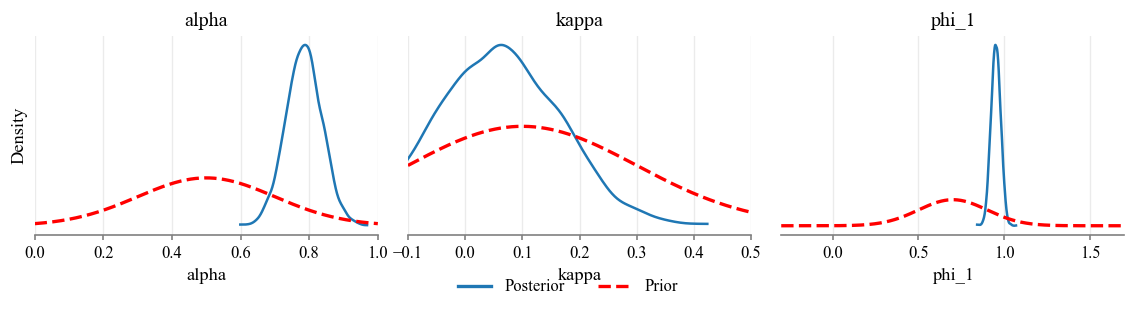

In [190]:
from func_show_results import plot_prior_posterior
for model_name, idata in dict_items_fill.items():
    priors = set_prior_distributions()
    fig = plot_prior_posterior(
        idatas=[idata],
        priors=priors,
        params=("alpha", "kappa", "phi_1"),
        grid=True,
        xlims={
        "kappa": (-0.1, 0.5),
        "alpha": (0, 1.0),
        "theta": (0.0, 1.0)}
    )
    plt.show()



## HSA (Dynamic effect only)
$$
\pi_{t} = \alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}-\theta \hat{N}_{t}+e_{t}\\
x_{t} = \phi_1 x_{t-1} + \zeta_{t}\\
N_{t} = \hat{N}_{t}+\bar{N}_{t}\\
\hat{N}_{t} = \rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N}_{t} = n+\bar{N}_{t-1}+\epsilon_{t}
$$
$$
\begin{bmatrix}e_t\\ \zeta_t\\ u_t\\ \epsilon_t \end{bmatrix}\sim 
N\!\left(0,\Sigma\right),\qquad
\Sigma=
\begin{bmatrix}
\sigma_e^2 & \sigma_{e\zeta} & \sigma_{eu} & 0\\ 
\sigma_{e\zeta} & \sigma_\zeta^2 & \sigma_{\zeta u} & 0\\
\sigma_{eu} & \sigma_{\zeta u}  & \sigma_{u}^2  & 0\\
0 & 0 & 0 & \sigma_{\epsilon}^2
\end{bmatrix}
$$

In [ ]:
def model_hsa_dynamic(pi, pi_prev, pi_expect, x, x_prev, N, l):
    priors = set_prior_distributions()
    
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    theta = numpyro.sample("theta", priors["theta"])
    
    # AR(1) param for x
    phi_1 = numpyro.sample("phi_1", priors["phi_1"])
    
    # State equation (N) params - AR(2) for cycle
    r = numpyro.sample("r", dist.Uniform(-1, 1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1)
    numpyro.deterministic("rho_2", rho_2)
    n = numpyro.sample("n", priors["n"])
    
    # Variance parameters
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"])
    sigma_zeta = numpyro.sample("sigma_zeta", priors["sigma_zeta"])
    sigma_u = numpyro.sample("sigma_u", priors["sigma_u"])
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"])
    
    # 3x3 correlation matrix for (e, zeta, u)
    corr_matrix = numpyro.sample("corr_matrix", dist.LKJCholesky(3, concentration=2.0))
    
    # Extract correlations as deterministic variables
    corr_full = corr_matrix @ corr_matrix.T
    numpyro.deterministic("rho_e_zeta", corr_full[0, 1])
    numpyro.deterministic("rho_e_u", corr_full[0, 2])
    numpyro.deterministic("rho_zeta_u", corr_full[1, 2])
    
    # Covariance matrix for (e, zeta, u)
    D = jnp.diag(jnp.array([sigma_e, sigma_zeta, sigma_u]))
    cov_3x3 = D @ corr_full @ D
    
    # Initial states
    # t=0
    bar_N_0 = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))
    hat_N_0 = numpyro.sample("hat_N_0", dist.Normal(0, 0.05)) 
    
    # t=-1
    hat_N_1 = numpyro.sample("hat_N_1", dist.Normal(0, 0.05)) 
        
    # ===== scan from t=1 onwards =====
    def transition(carry, t):
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        
        # Trend
        Nbar_t = numpyro.sample(f"Nbar_{t}", dist.Normal(n + Nbar_prev, sigma_eps))
        # Cycle
        Nhat_pred = rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2
        Nhat_obs = N[t] - Nbar_t
        u_t = Nhat_obs - Nhat_pred
        Nhat_t = numpyro.deterministic(f"Nhat_{t}", Nhat_obs)
        
        # X equation
        x_pred = phi_1 * x_prev[t]
        zeta_t = x[t] - x_pred
        
        # Pi equation
        pi_pred = alpha * pi_prev[t] + (1 - alpha) * pi_expect[t] + kappa * x[t] - theta * Nhat_t
        e_t = pi[t] - pi_pred
        
        # Joint residuals
        residuals = jnp.array([e_t, zeta_t, u_t])
        numpyro.sample(f"residuals_{t}", dist.MultivariateNormal(jnp.zeros(3), cov_3x3), obs=residuals)
        
        return [Nbar_t, Nhat_t, Nhat_prev_1], None
    
    timesteps = jnp.arange(1, l)
    init_carry = [bar_N_0, hat_N_0, hat_N_1]
    
    scan(transition, init_carry, timesteps)


model_dict = {
    "HSA dynamic": model_hsa_dynamic,
}
# 1) model
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x, x_prev = x_prev, N=N, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    # Divergence diagnostics
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")


=== Run models ===
Running NKPC model: HSA dynamic


sample: 100%|██████████| 5000/5000 [04:31<00:00, 18.42it/s, 511 steps of size 3.02e-02. acc. prob=0.92]


Divergence ratio for HSA dynamic: 0.0000%

=== All models finished ===



In [1]:
# dict_idata subset
# results
models_to_show ={
    "HSA dynamic",
}
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_normal(idata, "alpha", alpha_mu, alpha_sigma)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_phi_1 = sddr_normal(idata, "phi_1", phi_1_mu, phi_1_sigma)
    except Exception:
        bf01_phi_1 = np.nan
    try:
        bf01_kappa = sddr_normal(idata, "kappa", kappa_mu, kappa_sigma)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_normal(idata, "theta", theta_mu, theta_sigma)
    except Exception:
        bf01_theta = np.nan

    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_phi_1": bf01_phi_1,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_phi_1"] = df_sddr["SDDR_BF01_phi_1"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_kappa"] = df_sddr["SDDR_BF01_kappa"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")

display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "phi_1", "kappa", "theta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["sigma_e", "sigma_zeta", "sigma_e_zeta", "sigma_u_zeta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide_sig = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Coefficients Summary</h3>"))
display(summary_wide.style.hide(axis="index"))
display(summary_wide_sig.style.hide(axis="index"))

NameError: name 'dict_idata' is not defined

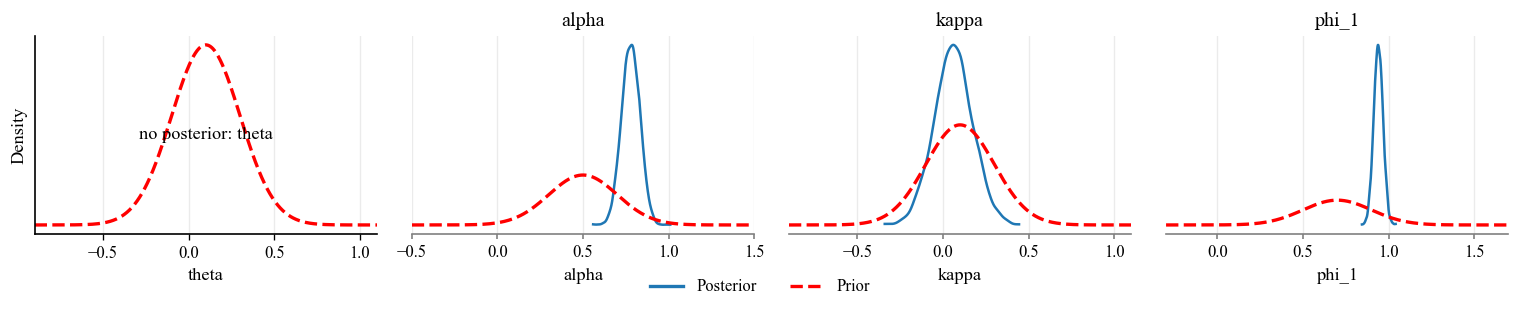

In [ ]:
for model_name, idata in dict_items_fill.items():
    priors = set_prior_distributions()
    fig = plot_prior_posterior(
        idatas=[idata],
        priors=priors,
        params=("alpha", "kappa", "phi_1"),
        grid=True
    )
    plt.show()


---
## HSA (Steady-State effect only)
$$
\pi_{t} = \alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1} + \kappa_{t} x_{t} + e_{t}\\
x_{t} = \phi_1 x_{t-1} + \zeta_{t}\\
N_{t} = \hat{N}_{t}+\bar{N}_{t}\\
\hat{N}_{t} = \rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N}_{t} = n+\bar{N}_{t-1}+\epsilon_{t}\\
\kappa_{t} = \kappa_{0}+\delta \bar{N}_{t}
$$
$$
\begin{bmatrix}e_t\\ \zeta_t\\ u_t\\ \epsilon_t \end{bmatrix}\sim 
N\!\left(0,\Sigma\right),\qquad
\Sigma=
\begin{bmatrix}
\sigma_e^2 & \sigma_{e\zeta} & 0 & 0\\ 
\sigma_{e\zeta} & \sigma_\zeta^2 & 0 & 0\\
0 & 0 & \sigma_{u}^2 & 0\\
0 & 0 & 0 & \sigma_{\epsilon}^2
\end{bmatrix}
$$


In [198]:
def model_hsa_steady(pi, pi_prev, pi_expect, x, x_prev, N, l):
    priors = set_prior_distributions()
    
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    delta = numpyro.sample("delta", priors["delta"])  
    
    # AR(1) param for x
    phi_1 = numpyro.sample("phi_1", priors["phi_1"])
    
    # State equation (N) params - AR(2) for cycle
    r = numpyro.sample("r", dist.Uniform(-1, 1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1)
    numpyro.deterministic("rho_2", rho_2)
    n = numpyro.sample("n", priors["n"])
    
    # Variance parameters
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"])
    sigma_zeta = numpyro.sample("sigma_zeta", priors["sigma_zeta"])
    sigma_u = numpyro.sample("sigma_u", priors["sigma_u"])
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"])
    
    # 3x3 correlation matrix for (e, zeta, u)
    corr_matrix = numpyro.sample("corr_matrix", dist.LKJCholesky(3, concentration=2.0))
    
    # Extract correlations as deterministic variables
    corr_full = corr_matrix @ corr_matrix.T
    numpyro.deterministic("rho_e_zeta", corr_full[0, 1])
    numpyro.deterministic("rho_e_u", corr_full[0, 2])
    numpyro.deterministic("rho_zeta_u", corr_full[1, 2])
    
    # Covariance matrix for (e, zeta, u)
    D = jnp.diag(jnp.array([sigma_e, sigma_zeta, sigma_u]))
    cov_3x3 = D @ corr_full @ D
    
    # Initial states
    # t=0
    bar_N_0 = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))
    hat_N_0 = numpyro.sample("hat_N_0", dist.Normal(0, 0.05)) 
    kappa_0 = numpyro.sample("kappa_0", priors["kappa"])
    # t=-1
    hat_N_1 = numpyro.sample("hat_N_1", dist.Normal(0, 0.05)) 
        
    # ===== scan from t=1 onwards =====
    def transition(carry, t):
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        
        # Trend
        Nbar_t = numpyro.sample(f"Nbar_{t}", dist.Normal(n + Nbar_prev, sigma_eps))
        # Cycle
        Nhat_pred = rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2
        Nhat_obs = N[t] - Nbar_t
        u_t = Nhat_obs - Nhat_pred
        Nhat_t = numpyro.deterministic(f"Nhat_{t}", Nhat_obs)
        
        # Time-varying params
        kappa_t = kappa_0 + delta * Nbar_t
        numpyro.deterministic(f"kappa_{t}", kappa_t)
        
        # X equation
        x_pred = phi_1 * x_prev[t]
        zeta_t = x[t] - x_pred
        
        # Pi equation
        pi_pred = alpha * pi_prev[t] + (1 - alpha) * pi_expect[t] + kappa * x[t]
        e_t = pi[t] - pi_pred
        
        # Joint residuals
        residuals = jnp.array([e_t, zeta_t, u_t])
        numpyro.sample(f"residuals_{t}", dist.MultivariateNormal(jnp.zeros(3), cov_3x3), obs=residuals)
        
        return [Nbar_t, Nhat_t, Nhat_prev_1], None
    
    timesteps = jnp.arange(1, l)
    init_carry = [bar_N_0, hat_N_0, hat_N_1]
    
    scan(transition, init_carry, timesteps)


model_dict = {
    "HSA steady": model_hsa_steady,
}
# 1) model
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x, x_prev = x_prev, N=N, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    # Divergence diagnostics
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")


=== Run models ===
Running NKPC model: HSA steady


sample: 100%|██████████| 5000/5000 [05:10<00:00, 16.08it/s, 255 steps of size 2.48e-02. acc. prob=0.95] 


Divergence ratio for HSA steady: 0.0000%

=== All models finished ===



In [199]:
# dict_idata subset
# results
models_to_show ={
    "HSA steady",
}
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_normal(idata, "alpha", alpha_mu, alpha_sigma)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_phi_1 = sddr_normal(idata, "phi_1", phi_1_mu, phi_1_sigma)
    except Exception:
        bf01_phi_1 = np.nan
    try:
        bf01_kappa = sddr_normal(idata, "kappa", kappa_mu, kappa_sigma)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_delta = sddr_normal(idata, "delta", delta_mu, delta_sigma)
    except Exception:
        bf01_delta = np.nan

    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_phi_1": bf01_phi_1,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_phi_1"] = df_sddr["SDDR_BF01_phi_1"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_kappa"] = df_sddr["SDDR_BF01_kappa"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")

display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "phi_1", "kappa", "delta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["sigma_e", "sigma_zeta", "sigma_e_zeta", "sigma_u_zeta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide_sig = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Coefficients Summary</h3>"))
display(summary_wide.style.hide(axis="index"))
display(summary_wide_sig.style.hide(axis="index"))

model,SDDR_BF01_alpha,SDDR_BF01_phi_1,SDDR_BF01_kappa,SDDR_BF01_delta
HSA steady,0.0,0.0,1.75,1.014


model,alpha,phi_1,kappa,delta
HSA steady,"0.7790 [0.6740, 0.8800]","0.9400 [0.8890, 0.9940]","0.0600 [-0.1610, 0.2810]","0.0980 [-0.2910, 0.4770]"


model,sigma_e,sigma_zeta,sigma_e_zeta,sigma_u_zeta
HSA steady,"2.6740 [2.3510, 3.0160]","0.5820 [0.5060, 0.6530]",nan,nan


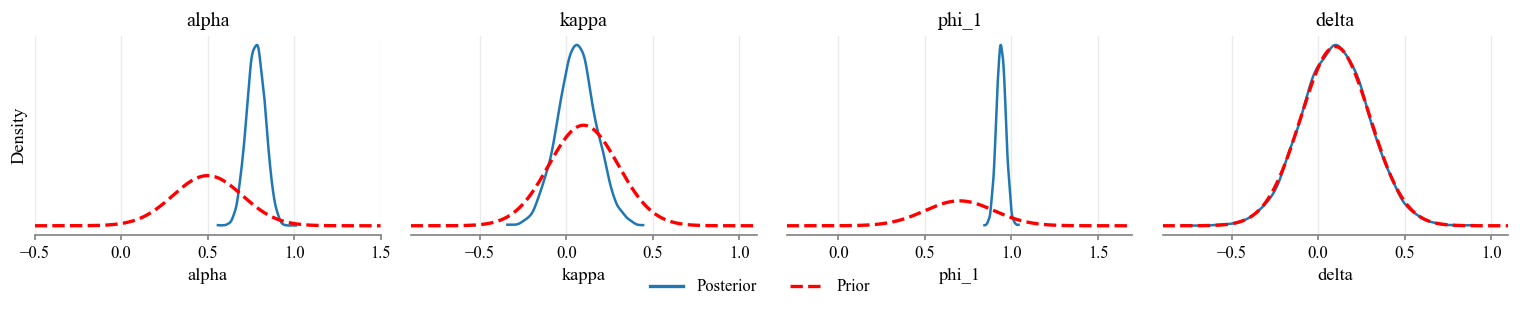

In [200]:
for model_name, idata in dict_items_fill.items():
    priors = set_prior_distributions()
    fig = plot_prior_posterior(
        idatas=[idata],
        priors=priors,
        params=("alpha", "kappa", "phi_1", "delta"),
        grid=True
    )
    plt.show()


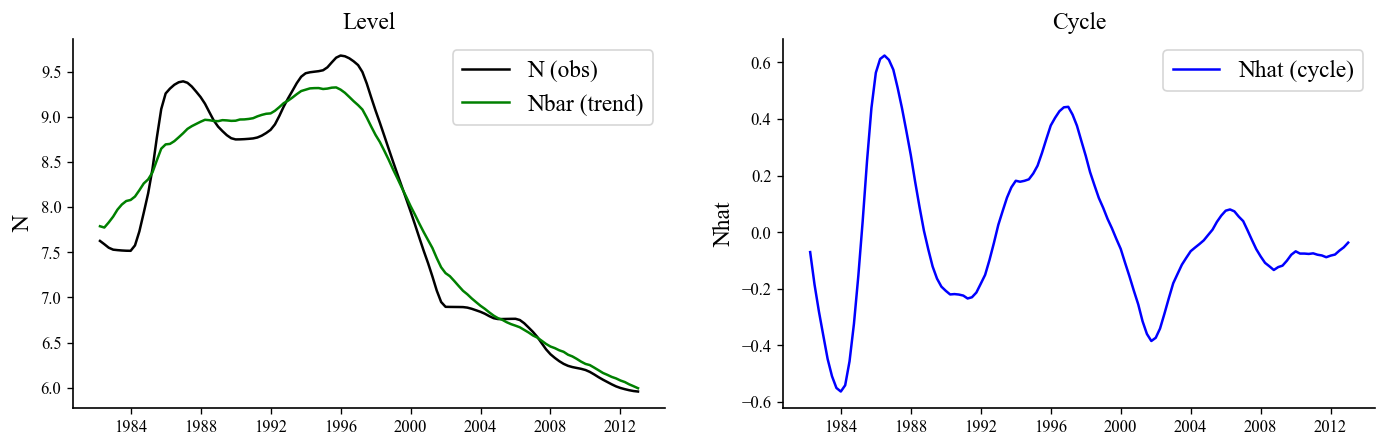

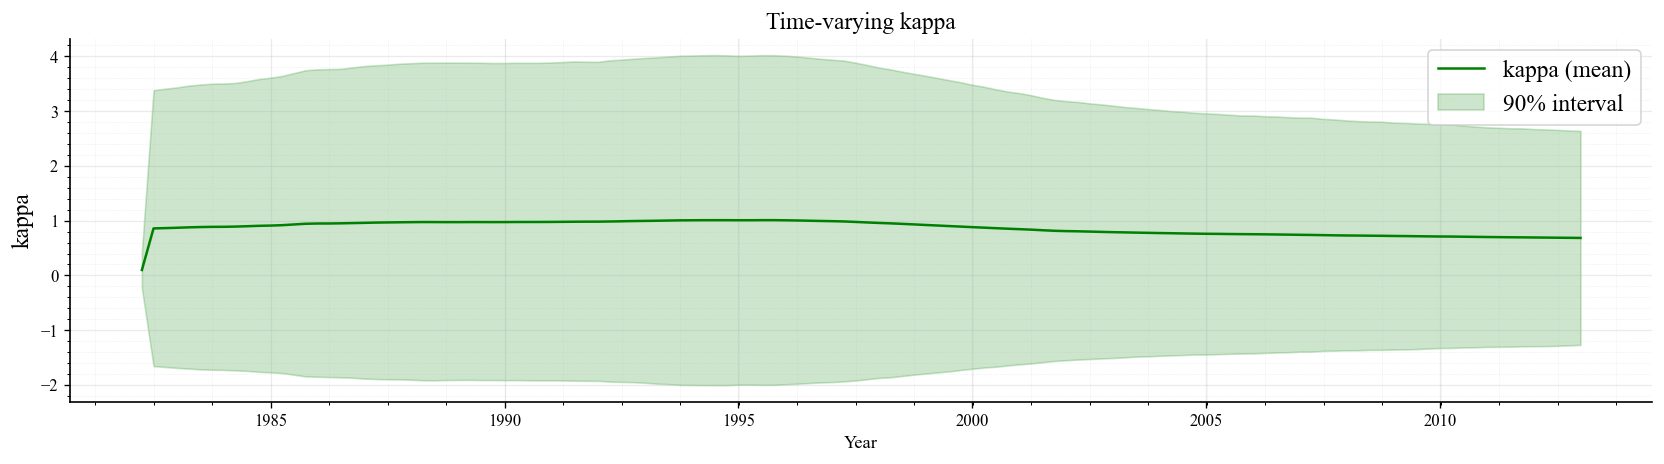

In [201]:
for model_name, idata in dict_items_fill.items():
        # ---- Samples ----
        t0 = idata.posterior["hat_N_0"].values
        t0_mean = float(np.mean(t0))
        Nhat_samples = idata.posterior["Nhat_JitTracer<int64[]>"].values
        Nhat_samples = Nhat_samples.reshape(-1, Nhat_samples.shape[-1])
        Nhat_mean = np.mean(Nhat_samples, axis=0)
        Nhat_mean = np.concatenate([[t0_mean], Nhat_mean])

        t0 = idata.posterior["bar_N_0"].values
        t0_mean = float(np.mean(t0))
        Nbar_samples = idata.posterior["Nbar_JitTracer<int64[]>"].values
        Nbar_samples = Nbar_samples.reshape(-1, Nbar_samples.shape[-1])
        Nbar_mean = np.mean(Nbar_samples, axis=0)
        Nbar_mean = np.concatenate([[t0_mean], Nbar_mean])

        t0 = idata.posterior["kappa_0"].values
        t0_mean = float(np.mean(t0))
        kappa_samples = idata.posterior["kappa_JitTracer<int64[]>"].values
        kappa_samples = kappa_samples.reshape(-1, kappa_samples.shape[-1])
        kappa_mean = np.mean(kappa_samples, axis=0)
        kappa_mean = np.concatenate([[t0_mean], kappa_mean])

        kappa_low_vec  = np.quantile(kappa_samples, 0.05, axis=0)
        kappa_high_vec = np.quantile(kappa_samples, 0.95, axis=0)
        t0_samps = t0.reshape(-1)
        kappa_low0  = float(np.quantile(t0_samps, 0.05))
        kappa_high0 = float(np.quantile(t0_samps, 0.95))
        kappa_low  = np.concatenate([[kappa_low0], kappa_low_vec])
        kappa_high = np.concatenate([[kappa_high0], kappa_high_vec])

        # ---- Figure: two panels ----
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 4), sharex=True)
        # =========================
        # Left panel: Level
        # =========================
        ax1.plot(data["DATE"], data["N"], label="N (obs)", color="black")
        ax1.plot(data["DATE"], Nbar_mean, label="Nbar (trend)", color="green")
        ax1.set_title("Level", fontsize=14)
        ax1.set_ylabel("N", fontsize=14)
        ax1.legend(loc="upper right", fontsize=14)

        # =========================
        # Right panel: Cycle
        # =========================
        ax2.plot(data["DATE"], Nhat_mean, label="Nhat (cycle)", color="blue")
        ax2.set_title("Cycle", fontsize=14)
        ax2.set_ylabel("Nhat", fontsize=14)
        ax2.legend(loc="upper right", fontsize=14)

        # kappa
        fig, ax = plt.subplots(figsize=(14, 4), sharex=True)
        dates = pd.to_datetime(data["DATE"]).to_numpy()
        T = min(len(dates), len(kappa_mean))
        dates = dates[:T]

        ax.plot(dates, kappa_mean[:T], label="kappa (mean)", color="green")
        ax.fill_between(dates, kappa_low[:T], kappa_high[:T], color="green", alpha=0.2, label="90% interval")

        ax.set_title("Time-varying kappa", fontsize=14)
        ax.set_ylabel("kappa", fontsize=14)
        ax.legend(loc="upper right", fontsize=14)

        ax.set_xlabel("Year")
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator(1))
        ax.minorticks_on()
        ax.grid(which="major", linestyle="-", linewidth=0.75)
        ax.grid(which="minor", linestyle=":", linewidth=0.5)

        plt.tight_layout()
        plt.show()

---
## HSA (Both effects)
$$
\pi_{t} = \alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1} + \kappa_{t} x_{t} -\theta_t \hat{N}_{t} + e_{t}\\
x_{t} = \phi_1 x_{t-1} + \zeta_{t}\\
$$
$$
N_{t} = \hat{N}_{t}+\bar{N}_{t}\\
\hat{N}_{t} = \rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N}_{t} = n+\bar{N}_{t-1}+\epsilon_{t}\\
$$
$$
\kappa_{t} = \kappa_{0}+ \delta \bar{N}_{t}\\
\theta_{t} = \theta_{0}+ \gamma \bar{N}_{t}
$$
$$
\begin{bmatrix}e_t\\ \zeta_t\\ u_t\\ \epsilon_t \end{bmatrix}\sim 
N\!\left(0,\Sigma\right),\qquad
\Sigma=
\begin{bmatrix}
\sigma_e^2 & \sigma_{e\zeta} & \sigma_{eu} & 0\\ 
\sigma_{e\zeta} & \sigma_\zeta^2 & \sigma_{\zeta u} & 0\\
\sigma_{eu} & \sigma_{\zeta u}  & \sigma_{u}^2  & 0\\
0 & 0 & 0 & \sigma_{\epsilon}^2
\end{bmatrix}
$$

### 1st step
$$
N_{t} = \hat{N}_{t}+\bar{N}_{t}\\
\hat{N}_{t} = \rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N}_{t} = n+\bar{N}_{t-1}+\epsilon_{t}\\
$$
---
$$
Y_{t} = \hat{Y}_{t}+\bar{Y}_{t}\\
\hat{Y}_{t} = \rho_{1}\hat{Y}_{t-1}+\rho_{2}\hat{Y}_{t-2}+\zeta_{t}\\
\bar{Y}_{t} = n+\bar{Y}_{t-1}+e_{t}\\
$$
---
---
### 2nd step
$$
\pi_{t} = \alpha\pi_{t-1}+(1-\alpha)\mathbb{E}^*_{t}\pi_{t+1} + \kappa_{t} x_{t} -\theta_t \hat{N}_{t} + \varepsilon_{t}\\
\mathbb{E}^*_{t}\pi_{t+1}  = \mathbb{E}_{t}\pi_{t+1} + \mu_{t}
$$

$$
\kappa_{t} = \kappa_{0}+ \delta \bar{N}_{t}\\
\theta_{t} = \theta_{0}+ \gamma \bar{N}_{t}
$$

$$
\begin{bmatrix}\varepsilon_t\\ \mu_t \end{bmatrix}\sim 
N(0,\Sigma),\qquad
\Sigma=\begin{bmatrix} \sigma_{\varepsilon} & 0 \\ 0 & \sigma_{\mu} \end{bmatrix}
$$

In [191]:
def model_hsa_both(pi, pi_prev, pi_expect, x, x_prev, N, l):
    priors = set_prior_distributions()
    
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    delta = numpyro.sample("delta", priors["delta"])
    gamma = numpyro.sample("gamma", priors["gamma"])  
    
    # AR(1) param for x
    phi_1 = numpyro.sample("phi_1", priors["phi_1"])
    
    # State equation (N) params - AR(2) for cycle
    r = numpyro.sample("r", dist.Uniform(-1, 1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1)
    numpyro.deterministic("rho_2", rho_2)
    n = numpyro.sample("n", priors["n"])
    
    # Variance parameters
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"])
    sigma_zeta = numpyro.sample("sigma_zeta", priors["sigma_zeta"])
    sigma_u = numpyro.sample("sigma_u", priors["sigma_u"])
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"])
    
    # 3x3 correlation matrix for (e, zeta, u)
    corr_matrix = numpyro.sample("corr_matrix", dist.LKJCholesky(3, concentration=2.0))
    
    # Extract correlations as deterministic variables
    corr_full = corr_matrix @ corr_matrix.T
    numpyro.deterministic("rho_e_zeta", corr_full[0, 1])
    numpyro.deterministic("rho_e_u", corr_full[0, 2])
    numpyro.deterministic("rho_zeta_u", corr_full[1, 2])
    
    # Covariance matrix for (e, zeta, u)
    D = jnp.diag(jnp.array([sigma_e, sigma_zeta, sigma_u]))
    cov_3x3 = D @ corr_full @ D
    
    # Initial states
    # t=0
    bar_N_0 = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))
    hat_N_0 = numpyro.sample("hat_N_0", dist.Normal(0, 0.05)) 
    kappa_0 = numpyro.sample("kappa_0", priors["kappa"])
    theta_0 = numpyro.sample("theta_0", priors["theta"])
    # t=-1
    hat_N_1 = numpyro.sample("hat_N_1", dist.Normal(0, 0.05)) 
        
    # ===== scan from t=1 onwards =====
    def transition(carry, t):
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        
        # Trend
        Nbar_t = numpyro.sample(f"Nbar_{t}", dist.Normal(n + Nbar_prev, sigma_eps))
        # Cycle
        Nhat_pred = rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2
        Nhat_obs = N[t] - Nbar_t
        u_t = Nhat_obs - Nhat_pred
        Nhat_t = numpyro.deterministic(f"Nhat_{t}", Nhat_obs)
        
        # Time-varying params
        kappa_t = kappa_0 + delta * Nbar_t
        theta_t = theta_0 + gamma * Nbar_t
        numpyro.deterministic(f"kappa_{t}", kappa_t)
        numpyro.deterministic(f"theta_{t}", theta_t)
        
        # X equation
        x_pred = phi_1 * x_prev[t]
        zeta_t = x[t] - x_pred
        
        # Pi equation
        pi_pred = alpha * pi_prev[t] + (1 - alpha) * pi_expect[t] + kappa_t * x[t] - theta_t * Nhat_t
        e_t = pi[t] - pi_pred
        
        # Joint residuals
        residuals = jnp.array([e_t, zeta_t, u_t])
        numpyro.sample(f"residuals_{t}", dist.MultivariateNormal(jnp.zeros(3), cov_3x3), obs=residuals)
        
        return [Nbar_t, Nhat_t, Nhat_prev_1], None
    
    timesteps = jnp.arange(1, l)
    init_carry = [bar_N_0, hat_N_0, hat_N_1]
    
    scan(transition, init_carry, timesteps)


model_dict = {
    "HSA full": model_hsa_both,
}
# 1) model
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x, x_prev = x_prev, N=N, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    # Divergence diagnostics
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")


=== Run models ===
Running NKPC model: HSA full


sample: 100%|██████████| 5000/5000 [05:29<00:00, 15.19it/s, 255 steps of size 2.13e-02. acc. prob=0.96] 


Divergence ratio for HSA full: 0.0000%

=== All models finished ===



In [192]:
# dict_idata subset
# results
models_to_show ={
    "HSA full",
}
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_normal(idata, "alpha", alpha_mu, alpha_sigma)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_phi_1 = sddr_normal(idata, "phi_1", phi_1_mu, phi_1_sigma)
    except Exception:
        bf01_phi_1 = np.nan
    try:
        bf01_delta = sddr_normal(idata, "delta", delta_mu, delta_sigma)
    except Exception:
        bf01_delta = np.nan
    try:
        bf01_gamma = sddr_normal(idata, "gamma", gamma_mu, gamma_sigma)
    except Exception:
        bf01_gamma = np.nan

    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_phi_1": bf01_phi_1,
        "SDDR_BF01_delta": bf01_delta,
        "SDDR_BF01_gamma": bf01_gamma,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_phi_1"] = df_sddr["SDDR_BF01_phi_1"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_gamma"] = df_sddr["SDDR_BF01_gamma"].map(lambda v: f"{v:.4}")

display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "phi_1", "delta", "gamma"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["sigma_e", "sigma_zeta", "sigma_e_zeta", "sigma_u_zeta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide_sig = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Coefficients Summary</h3>"))
display(summary_wide.style.hide(axis="index"))
display(summary_wide_sig.style.hide(axis="index"))



model,SDDR_BF01_alpha,SDDR_BF01_phi_1,SDDR_BF01_delta,SDDR_BF01_gamma
HSA full,0.0,0.0,6.853,1.511


model,alpha,phi_1,delta,gamma
HSA full,"0.7780 [0.6720, 0.8780]","0.9400 [0.8870, 0.9940]","0.0080 [-0.0560, 0.0720]","-0.0440 [-0.2790, 0.1990]"


model,sigma_e,sigma_zeta,sigma_e_zeta,sigma_u_zeta
HSA full,"2.6860 [2.3550, 3.0410]","0.5820 [0.5110, 0.6550]",nan,nan


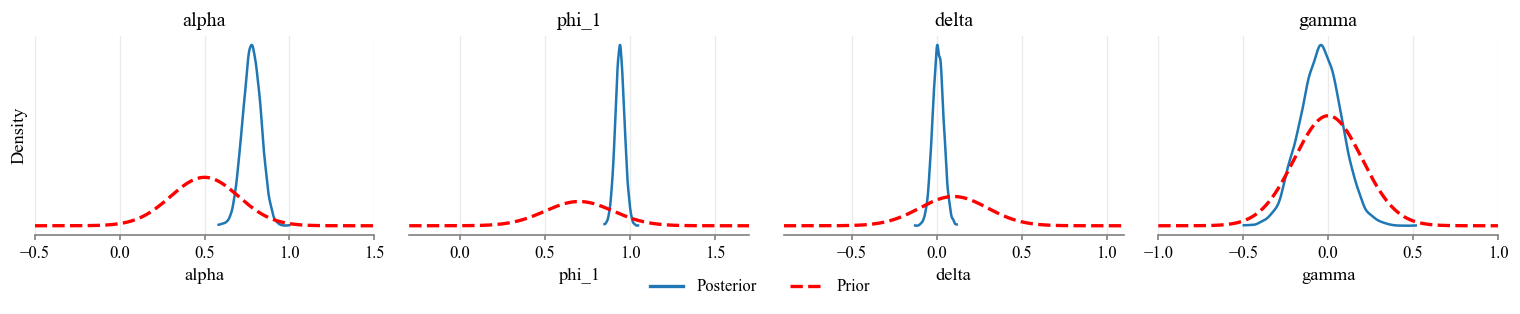

In [193]:
for model_name, idata in dict_items_fill.items():
    priors = set_prior_distributions()
    fig = plot_prior_posterior(
        idatas=[idata],
        priors=priors,
        params=("alpha", "phi_1", "delta", "gamma"),
        grid=True
    )
    plt.show()


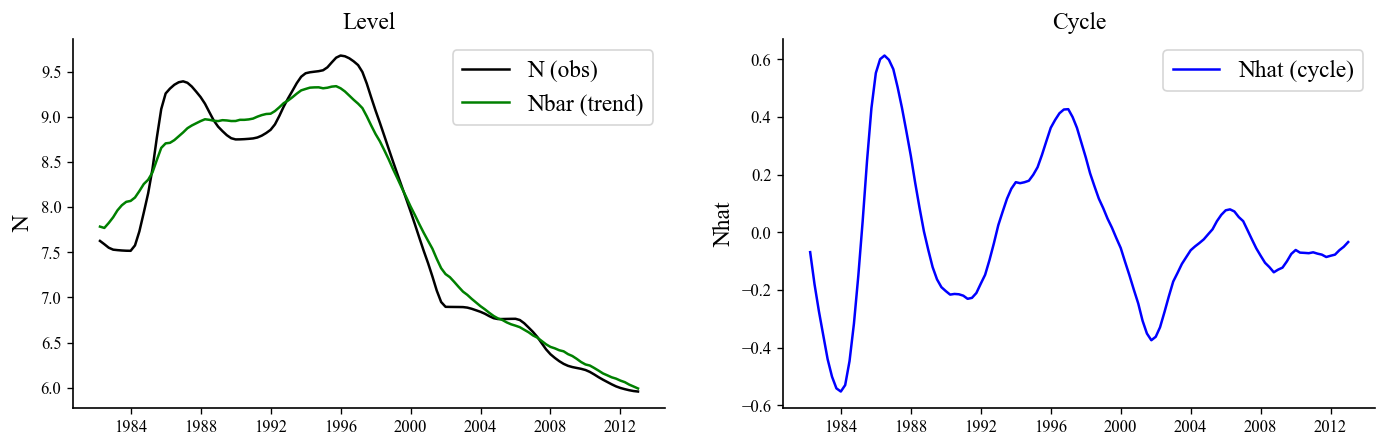

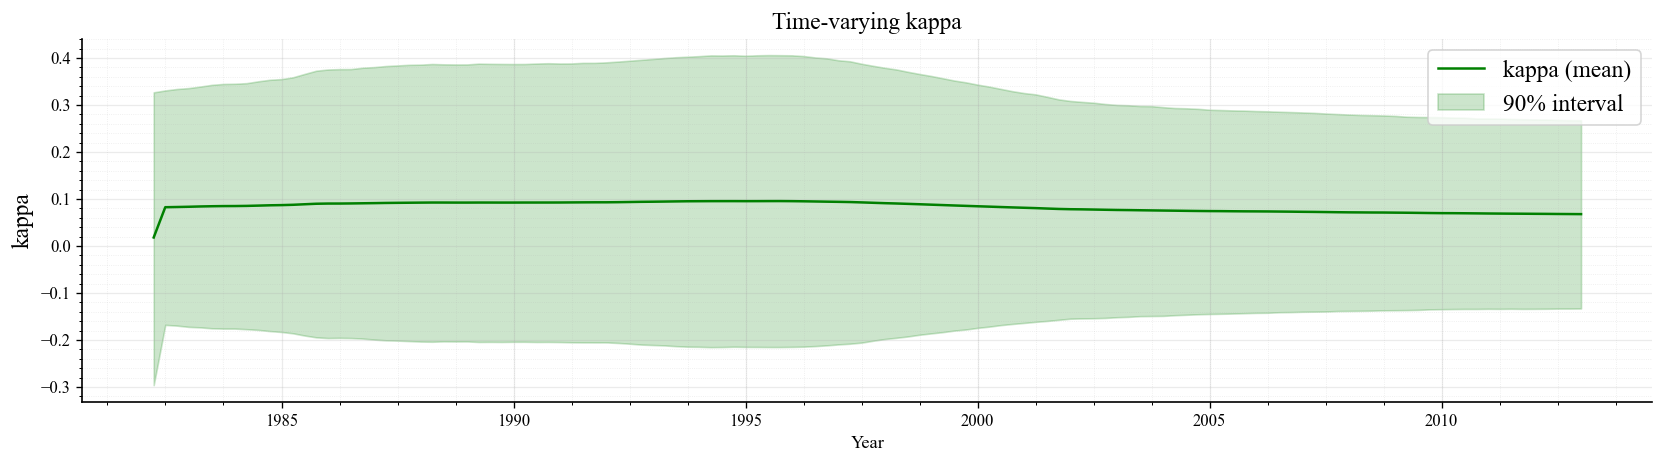

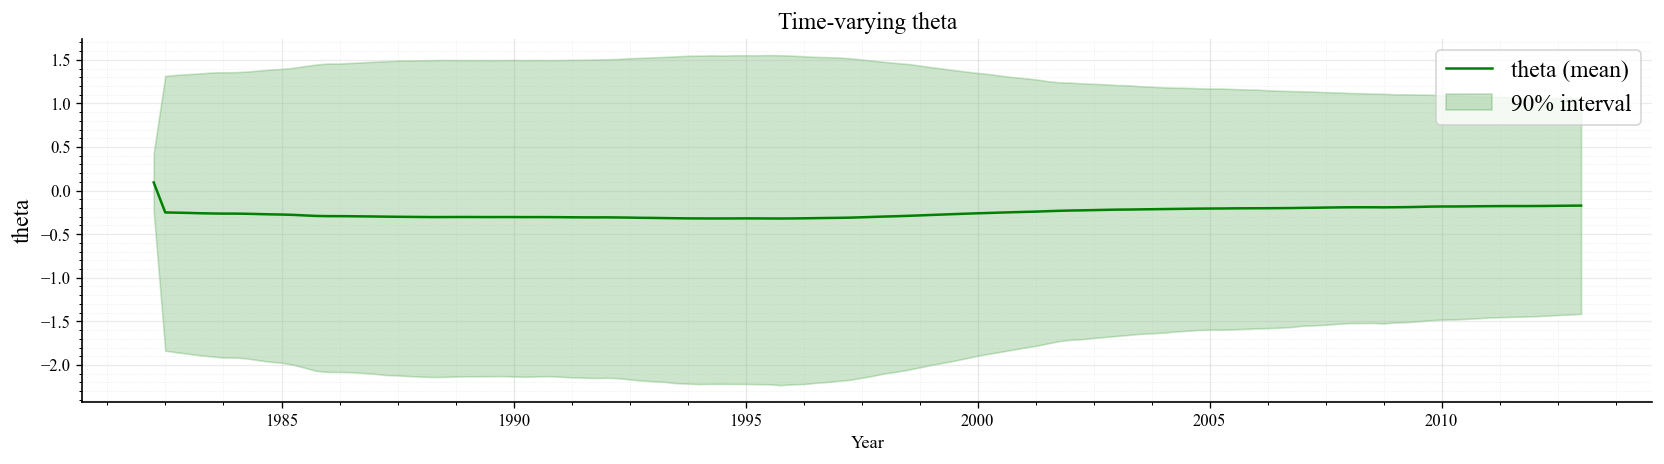

In [194]:
for model_name, idata in dict_items_fill.items():
        # ---- Samples ----
        t0 = idata.posterior["hat_N_0"].values
        t0_mean = float(np.mean(t0))
        Nhat_samples = idata.posterior["Nhat_JitTracer<int64[]>"].values
        Nhat_samples = Nhat_samples.reshape(-1, Nhat_samples.shape[-1])
        Nhat_mean = np.mean(Nhat_samples, axis=0)
        Nhat_mean = np.concatenate([[t0_mean], Nhat_mean])

        t0 = idata.posterior["bar_N_0"].values
        t0_mean = float(np.mean(t0))
        Nbar_samples = idata.posterior["Nbar_JitTracer<int64[]>"].values
        Nbar_samples = Nbar_samples.reshape(-1, Nbar_samples.shape[-1])
        Nbar_mean = np.mean(Nbar_samples, axis=0)
        Nbar_mean = np.concatenate([[t0_mean], Nbar_mean])

        t0 = idata.posterior["kappa_0"].values
        t0_mean = float(np.mean(t0))
        kappa_samples = idata.posterior["kappa_JitTracer<int64[]>"].values
        kappa_samples = kappa_samples.reshape(-1, kappa_samples.shape[-1])
        kappa_mean = np.mean(kappa_samples, axis=0)
        kappa_mean = np.concatenate([[t0_mean], kappa_mean])

        kappa_low_vec  = np.quantile(kappa_samples, 0.05, axis=0)
        kappa_high_vec = np.quantile(kappa_samples, 0.95, axis=0)
        t0_samps = t0.reshape(-1)
        kappa_low0  = float(np.quantile(t0_samps, 0.05))
        kappa_high0 = float(np.quantile(t0_samps, 0.95))
        kappa_low  = np.concatenate([[kappa_low0], kappa_low_vec])
        kappa_high = np.concatenate([[kappa_high0], kappa_high_vec])

        t0 = idata.posterior["theta_0"].values
        t0_mean = float(np.mean(t0))
        theta_samples = idata.posterior["theta_JitTracer<int64[]>"].values
        theta_samples = theta_samples.reshape(-1, theta_samples.shape[-1])
        theta_mean = np.mean(theta_samples, axis=0)
        theta_mean = np.concatenate([[t0_mean], theta_mean])

        theta_low_vec  = np.quantile(theta_samples, 0.05, axis=0)
        theta_high_vec = np.quantile(theta_samples, 0.95, axis=0)
        t0_samps = t0.reshape(-1)
        theta_low0  = float(np.quantile(t0_samps, 0.05))
        theta_high0 = float(np.quantile(t0_samps, 0.95))
        theta_low  = np.concatenate([[theta_low0], theta_low_vec])
        theta_high = np.concatenate([[theta_high0], theta_high_vec])

        # ---- Figure: two panels ----
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 4), sharex=True)
        # =========================
        # Left panel: Level
        # =========================
        ax1.plot(data["DATE"], data["N"], label="N (obs)", color="black")
        ax1.plot(data["DATE"], Nbar_mean, label="Nbar (trend)", color="green")
        ax1.set_title("Level", fontsize=14)
        ax1.set_ylabel("N", fontsize=14)
        ax1.legend(loc="upper right", fontsize=14)

        # =========================
        # Right panel: Cycle
        # =========================
        ax2.plot(data["DATE"], Nhat_mean, label="Nhat (cycle)", color="blue")
        ax2.set_title("Cycle", fontsize=14)
        ax2.set_ylabel("Nhat", fontsize=14)
        ax2.legend(loc="upper right", fontsize=14)

        # kappa
        fig, ax = plt.subplots(figsize=(14, 4), sharex=True)
        dates = pd.to_datetime(data["DATE"]).to_numpy()
        T = min(len(dates), len(kappa_mean))
        dates = dates[:T]

        ax.plot(dates, kappa_mean[:T], label="kappa (mean)", color="green")
        ax.fill_between(dates, kappa_low[:T], kappa_high[:T], color="green", alpha=0.2, label="90% interval")

        ax.set_title("Time-varying kappa", fontsize=14)
        ax.set_ylabel("kappa", fontsize=14)
        ax.legend(loc="upper right", fontsize=14)

        ax.set_xlabel("Year")
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator(1))
        ax.minorticks_on()
        ax.grid(which="major", linestyle="-", linewidth=0.75)
        ax.grid(which="minor", linestyle=":", linewidth=0.5)

        plt.tight_layout()
        plt.show()

        # theta
        fig, ax = plt.subplots(figsize=(14, 4), sharex=True)
        dates = pd.to_datetime(data["DATE"]).to_numpy()
        T = min(len(dates), len(kappa_mean))
        dates = dates[:T]

        ax.plot(dates, theta_mean[:T], label="theta (mean)", color="green")
        ax.fill_between(dates, theta_low[:T], theta_high[:T], color="green", alpha=0.2, label="90% interval")

        ax.set_title("Time-varying theta", fontsize=14)
        ax.set_ylabel("theta", fontsize=14)
        ax.legend(loc="upper right", fontsize=14)

        ax.set_xlabel("Year")
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator(1))
        ax.minorticks_on()
        ax.grid(which="major", linestyle="-", linewidth=0.75)
        ax.grid(which="minor", linestyle=":", linewidth=0.5)

        plt.tight_layout()
        plt.show()
